這個實驗應該不太對，因為還是需要訓練L_DSM

# 1.

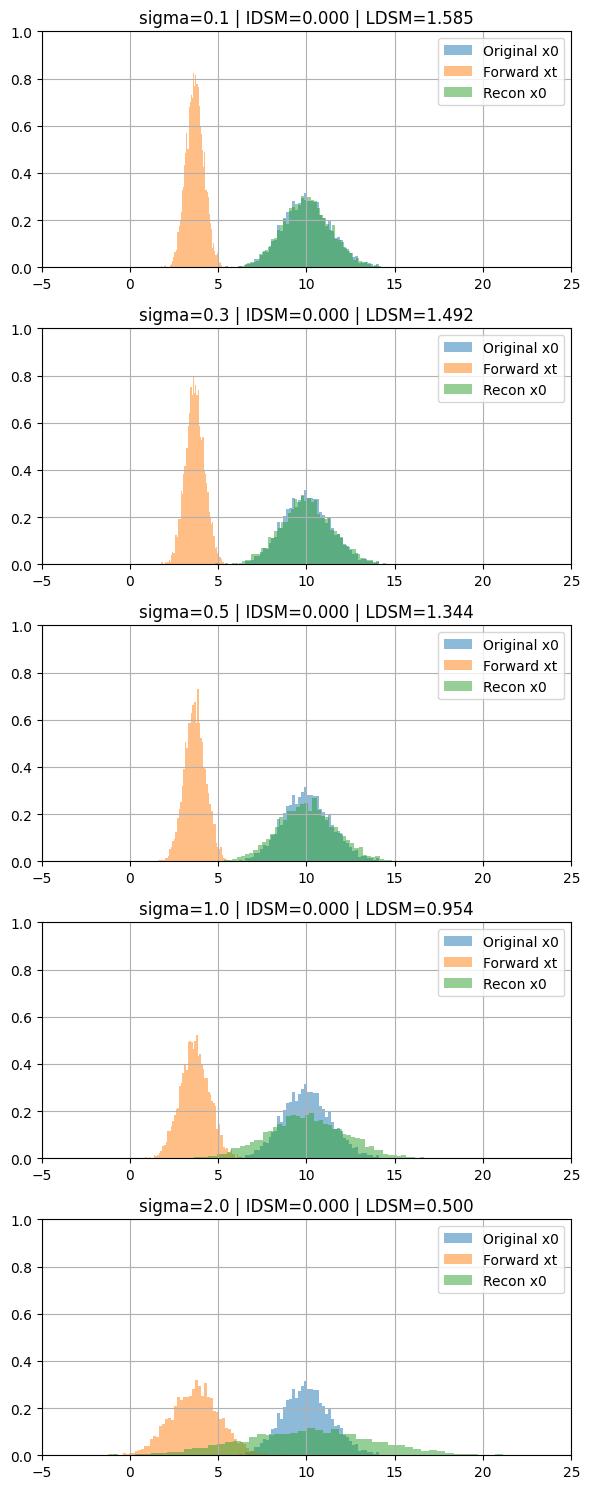

In [1]:
import numpy as np
import matplotlib.pyplot as plt

beta = 1.0
t = 1.0
dt = 0.001

mu0 = 10
std0 = np.sqrt(2)

sigmas = [0.1, 0.3, 0.5, 1.0, 2.0]

N = 5000
steps = int(t / dt)

x0 = np.random.normal(mu0, std0, N)

fig, axes = plt.subplots(len(sigmas), 1, figsize=(6, 3 * len(sigmas)))

for row, sigma in enumerate(sigmas):

    x = x0.copy()

    # forward OU process
    for _ in range(steps):

        noise = np.random.randn(N)

        x = x - beta * x * dt + sigma * np.sqrt(dt) * noise

    xt = x.copy()

    # reverse reconstruction
    x_recon = xt.copy()

    for _ in range(steps):

        x_recon = x_recon + beta * x_recon * dt

    mean_t = np.mean(xt)
    var_t = np.var(xt)

    score = -(xt - mean_t) / var_t
    
    # IDSM
    S_theta = score
    idsm = np.mean((score - S_theta) * score)
    
    # LDSM
    ldsm = (1/(sigma**2*t)) * np.log(
    (
        std0**2 + (sigma**2/(2*beta))*(np.exp(2*beta*t)-1)
    ) / std0**2
        )

    # same axis plotting
    axes[row].hist(x0, bins=60, density=True, alpha=0.5, label="Original x0")
    axes[row].hist(xt, bins=60, density=True, alpha=0.5, label="Forward xt")
    axes[row].hist(x_recon, bins=60, density=True, alpha=0.5, label="Recon x0")

    axes[row].set_title(
        f"sigma={sigma} | IDSM={idsm:.3f} | LDSM={ldsm:.3f}"
    )
    
    axes[row].set_xlim(-5, 25)
    axes[row].set_ylim(0, 1)
    axes[row].legend()
    axes[row].grid()

plt.tight_layout()
plt.show()

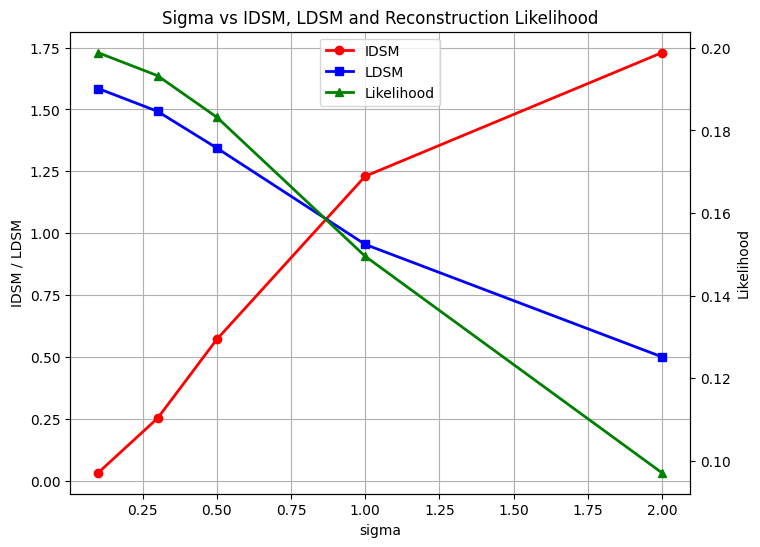

In [2]:
import numpy as np
import matplotlib.pyplot as plt

beta = 1.0
t = 1.0
dt = 0.001

mu0 = 10
var0 = 2
std0 = np.sqrt(var0)

sigmas = [0.1, 0.3, 0.5, 1.0, 2.0]

N = 5000
steps = int(t / dt)

x0 = np.random.normal(mu0, std0, N)

idsm_values = []
ldsm_values = []
likelihood_values = []

for sigma in sigmas:

    x = x0.copy()

    # forward OU
    for _ in range(steps):

        noise = np.random.randn(N)

        x = x - beta * x * dt + sigma * np.sqrt(dt) * noise

    xt = x.copy()

    # reverse reconstruction
    x_recon = xt.copy()

    for _ in range(steps):

        x_recon = x_recon + beta * x_recon * dt

    # =====================================
    # IDSM
    # =====================================

    noise_var = (sigma**2 / (2 * beta)) * (1 - np.exp(-2 * beta * t))

    idsm = 1 / ((1 / var0)+(np.exp(-2 * beta * t)/ noise_var))

    # =====================================
    # LDSM
    # =====================================

    mean_t = np.mean(xt)
    var_t = np.var(xt)

    score = -(xt - mean_t) / var_t

    ldsm = (1/(sigma**2*t)) * np.log(
    (
        var0 + (sigma**2/(2*beta))*(np.exp(2*beta*t)-1)
    ) / var0
        )

    # =====================================
    # likelihood
    # =====================================

    pdf = (
        1 / np.sqrt(2 * np.pi * var0)
    ) * np.exp(
        -(x_recon - mu0)**2 / (2 * var0)
    )

    likelihood = np.mean(pdf)

    # save
    idsm_values.append(idsm)
    ldsm_values.append(ldsm)
    likelihood_values.append(likelihood)

# =========================================
# plotting
# =========================================

import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(8,6))

# =====================================
# left y-axis
# =====================================

line1 = ax1.plot(
    sigmas,
    idsm_values,
    color='red',
    marker='o',
    linewidth=2,
    label='IDSM'
)

line2 = ax1.plot(
    sigmas,
    ldsm_values,
    color='blue',
    marker='s',
    linewidth=2,
    label='LDSM'
)

ax1.set_xlabel("sigma")
ax1.set_ylabel("IDSM / LDSM")

# =====================================
# right y-axis
# =====================================

ax2 = ax1.twinx()

line3 = ax2.plot(
    sigmas,
    likelihood_values,
    color='green',
    marker='^',
    linewidth=2,
    label='Likelihood'
)

ax2.set_ylabel("Likelihood")

# =====================================
# combine legends
# =====================================

lines = line1 + line2 + line3

labels = [l.get_label() for l in lines]

ax1.legend(lines, labels, loc='upper center')

plt.title("Sigma vs IDSM, LDSM and Reconstruction Likelihood")

ax1.grid()

plt.show()

**LDSM**隨著$\sigma$越大而變小?
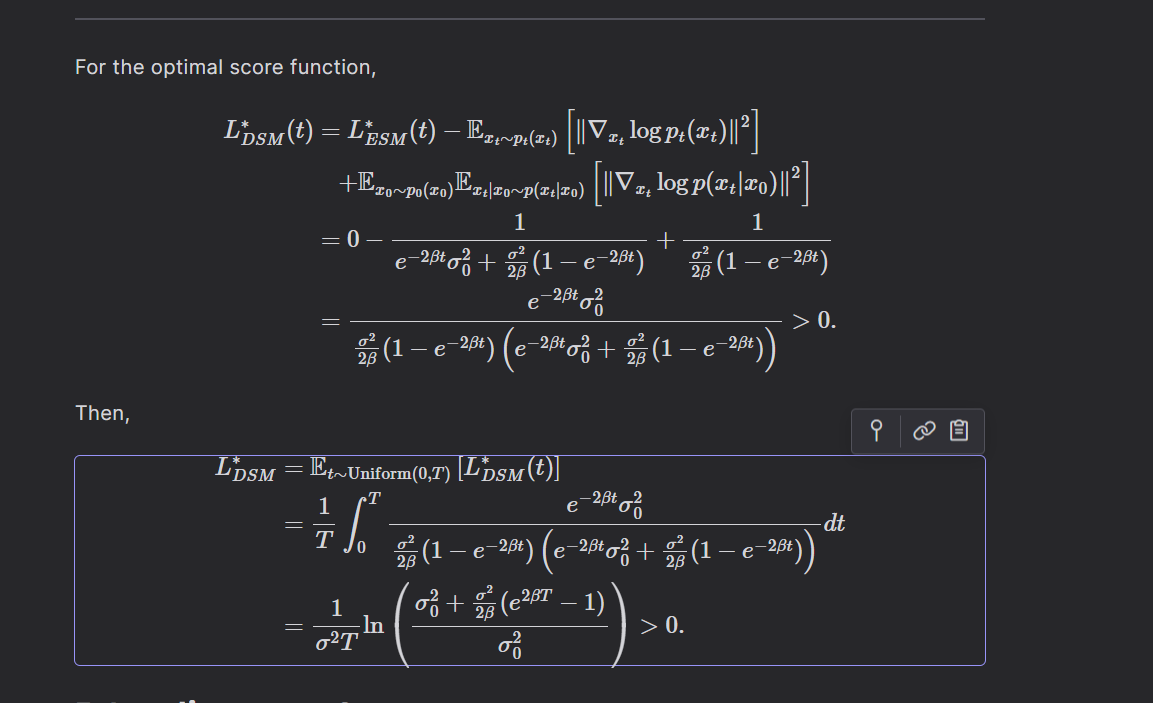

目前數據:
| sigma | IDSM   | Likelihood |
| ----- | ------ | ---------- |
| 0.1   | 0.031  | 0.20       |
| 0.3   | 0.284  | 0.195      |
| 0.5   | 0.818  | 0.182      |
| 1.0   | 3.213  | 0.150      |
| 2.0   | 12.287 | 0.098      |
